Solar power plant analysis
Analysis of real solar power generation data from India

Dataset:
- Source: Kaggle
- Period: May-June 2020
- Plants: 2 solar insallations

About Dataset
This data has been gathered at two solar power plants in India over a 34 day period. It has two pairs of files - each pair has one power generation dataset and one sensor readings dataset. The power generation datasets are gathered at the inverter level - each inverter has multiple lines of solar panels attached to it. The sensor data is gathered at a plant level - single array of sensors optimally placed at the plant.

Observations recorded every 15 min



In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Upload one file
#from google.colab import files
#uploaded = files.upload()

from google.colab import drive
drive.mount('/content/drive')

# Then read your files directly from Drive
df = pd.read_csv('/content/drive/MyDrive/projects/solar_power/data/Plant_1_Generation_Data.csv')

# Load data
#df = pd.read_csv('Plant_1_Generation_Data.csv')
print("Data loaded")
print(f"Shape: {df.shape}")
# formatted string, let's you insert variables directly into string


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded
Shape: (68778, 7)


In [10]:
# peak at columns
print("Columns:", df.columns.tolist())

# are there missing values?
print("\nMissing values:")
# \n just means new line
print(df.isnull().sum())

# basic stats
df.describe()

Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


/tmp/ipython-input-2831621443.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])


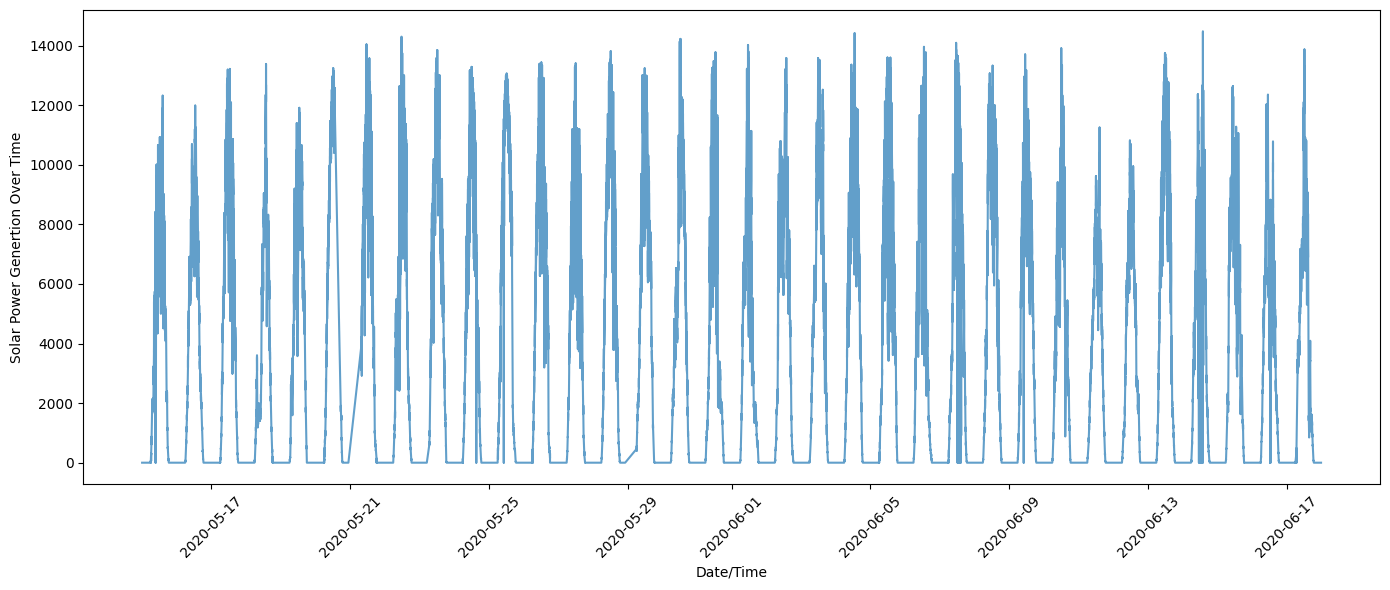

In [11]:
# One simple visualisation

# Convert timestamp
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# plot DC power over time
plt.figure(figsize=(14,6))
plt.plot(df['DATE_TIME'], df['DC_POWER'], alpha=0.7)
plt.xlabel('Date/Time')
plt.ylabel('Solar Power Genertion Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's add the weather data!

In [13]:
# upload weather file
from google.colab import files
weather_df = pd.read_csv('/content/drive/MyDrive/projects/solar_power/data/Plant_1_Weather_Sensor_Data.csv')
print("Data loaded")
print(f"Shape: {weather_df.shape}")
weather_df.head()


Data loaded
Shape: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [14]:
# check what's in the file
print("Weather columns:", weather_df.columns.tolist())
print("\nMissing values:")
print(weather_df.isnull().sum())

Weather columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [15]:
# Merge datasets

# convert timestamps
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])
weather_df.head()

# Merge
merged_df = pd.merge(df, weather_df, on='DATE_TIME', how='inner')
print(f"Merged dataset shape: {merged_df.shape}")
merged_df.head()

# Check what happened
print(f"Generation data: {len(df)} rows")
print(f"Weather data: {len(weather_df)} rows")
print(f"Merged data: {len(merged_df)} rows")
print(f"\nRows with matching timestamps: {len(merged_df)}")
print(f"Percentage of generation data kept: {(len(merged_df)/len(df))*100:.1f}%")

# Check for missing values in merged data
print(f"\nMissing values in merged data:")
print(merged_df.isnull().sum())

merged_df.head()


Merged dataset shape: (68774, 12)
Generation data: 68778 rows
Weather data: 3182 rows
Merged data: 68774 rows

Rows with matching timestamps: 68774
Percentage of generation data kept: 100.0%

Missing values in merged data:
DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


Analysis: Irradiation vs Power

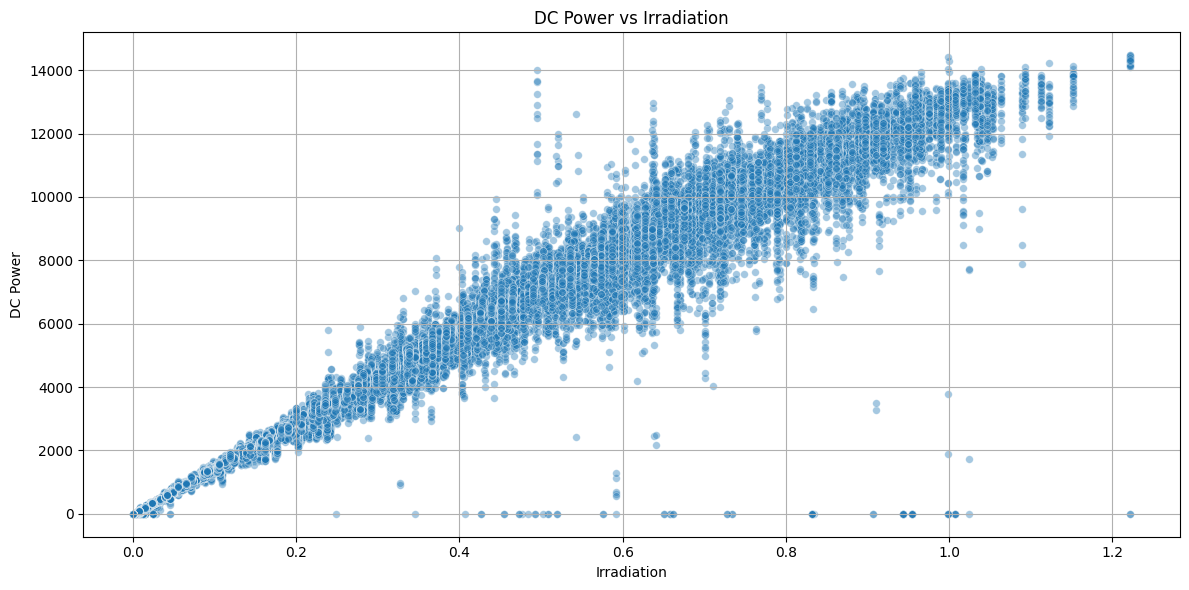


 Correlation between irradiation and power: 0.989
(1.0 = perfect positive correlation, 0 = no correlation)


In [16]:
# Create scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(x=merged_df['IRRADIATION'],y=merged_df['DC_POWER'],s=30, alpha=0.4)
plt.xlabel('Irradiation')
plt.ylabel('DC Power')
plt.title('DC Power vs Irradiation')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = merged_df['IRRADIATION'].corr(merged_df['DC_POWER'])
print(f"\n Correlation between irradiation and power: {correlation:.3f}")
print("(1.0 = perfect positive correlation, 0 = no correlation)")

Finding: Irradiation drives power output

The correlation between solar irradiation and DC power is [0.989], showing a strong postive relationship.
This makes sense: more light hitting the panels = more electricity generated.

Analysis: Temperature vs Power
Let's see if high temperatures can reduce panel efficiency

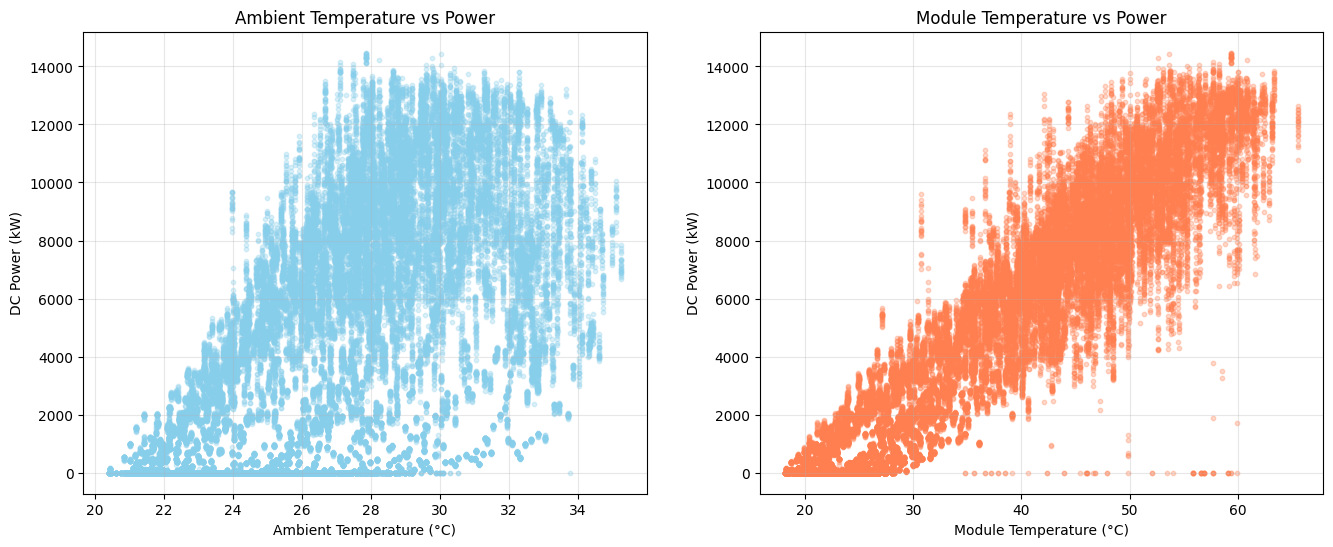

Correlation between ambient temperature and power: 0.725
Correlation between module temperature and power: 0.955


In [17]:
from matplotlib import color_sequences
# Plot temperature vs power
fig, axes = plt.subplots(1,2, figsize=[16,6])

# Ambient temperature
axes[0].scatter(merged_df['AMBIENT_TEMPERATURE'], merged_df['DC_POWER'],
                alpha=0.3, s=10, color='skyblue')
axes[0].set_xlabel('Ambient Temperature (°C)')
axes[0].set_ylabel('DC Power (kW)')
axes[0].set_title('Ambient Temperature vs Power')
axes[0].grid(True, alpha=0.3)

# Module (panel) temperature
axes[1].scatter(merged_df['MODULE_TEMPERATURE'], merged_df['DC_POWER'],
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Module Temperature (°C)')
axes[1].set_ylabel('DC Power (kW)')
axes[1].set_title('Module Temperature vs Power')
axes[1].grid(True, alpha=0.3)

plt.tight_layout
plt.show()

#correlations
corr_ambient = merged_df['AMBIENT_TEMPERATURE'].corr(merged_df['DC_POWER'])
corr_module = merged_df['MODULE_TEMPERATURE'].corr(merged_df['DC_POWER'])

print(f"Correlation between ambient temperature and power: {corr_ambient:.3f}")
print(f"Correlation between module temperature and power: {corr_module:.3f}")

Now let's figure out what the best and worst days are for solar generation


In [18]:
# Just a little check up

# Original generation data size
print("Generation data shape:", df.shape)

# Original weather data size
print("Weather data shape:", weather_df.shape)

# Merged data size
print("Merged data shape:", merged_df.shape)

# Check unique timestamps in generation data
print("\nGeneration data unique timestamps:", df['DATE_TIME'].nunique())

# Check unique timestamps in weather data
print("Weather data unique timestamps:", weather_df['DATE_TIME'].nunique())

# Check unique timestamps in merged data
print("Merged data unique timestamps:", merged_df['DATE_TIME'].nunique())

Generation data shape: (68778, 7)
Weather data shape: (3182, 6)
Merged data shape: (68774, 12)

Generation data unique timestamps: 3158
Weather data unique timestamps: 3182
Merged data unique timestamps: 3157


There were 4 timestamps in the generation data that didn't exist in the weather data, OR there were timestamps in weather data that didn't exist in generation data ----> we have 4 rows less in the merged data than in the generation data.
Maybe a sensor stopped recording briefly, there was a time mistmatch (generation recorded at 12:00:01 but weather recorded at 12:00:00).
OR there are data gaps in one dataset.
But 4 rows in a 68,778 long dataset shouldn't affect the analysis.

In [19]:
# Highest production days, using daily_yield at the end of each day

# Create new column with just date (no time)
merged_df['DATE'] = merged_df['DATE_TIME'].dt.date

# look at one inverter across a full day
one_inverter_one_day = merged_df[
    (merged_df['SOURCE_KEY_x'] == merged_df['SOURCE_KEY_x'].iloc[0]) &
    (merged_df['DATE'] == merged_df['DATE'].iloc[0])
]
print(one_inverter_one_day[['DATE_TIME', 'DAILY_YIELD', 'AC_POWER']])


               DATE_TIME  DAILY_YIELD  AC_POWER
0    2020-05-15 00:00:00          0.0       0.0
21   2020-05-15 00:15:00          0.0       0.0
42   2020-05-15 00:30:00          0.0       0.0
63   2020-05-15 00:45:00          0.0       0.0
84   2020-05-15 01:00:00          0.0       0.0
...                  ...          ...       ...
1844 2020-05-15 22:00:00       5754.0       0.0
1866 2020-05-15 22:15:00       5754.0       0.0
1888 2020-05-15 22:30:00       5754.0       0.0
1910 2020-05-15 22:45:00       5754.0       0.0
1932 2020-05-15 23:00:00       5754.0       0.0

[93 rows x 3 columns]


We can see exactly what's happening with ONE inverter on ONE day (May 15th).
nb. daily yield is cumulative and stays constant once the sun sets.
So if we want to know the highest and lowest production days we need to:
1. get maximum DAILY_YIELD for each inverter for each day.
2. Sum across all inverters to get total plant production per day
3. Sort highest and lowest days


In [20]:
# Step 1: Get max daily yield for each inverter on each day
daily_per_inverter = merged_df.groupby(['DATE', 'SOURCE_KEY_x'])['DAILY_YIELD'].max()
#print("Daily production per inverter:")
#print(daily_per_inverter.head(30))

# Step 2: Sum across all inverters to get total plant production per day
daily_production = daily_per_inverter.groupby('DATE').sum()
#print("Daily production summed over all inverters:")
#print(daily_production.head(30))

# Step 3: Sort highest and lowest days
highest_days = daily_production.nlargest(10)
lowest_days = daily_production.nsmallest(10)
print("Highest production days:")
print(highest_days)
print("Lowest production days:")
print(lowest_days)


Highest production days:
DATE
2020-05-20    193770.000000
2020-05-25    192862.000000
2020-05-23    186728.000000
2020-06-13    185308.000000
2020-05-28    183432.000000
2020-06-08    182943.000000
2020-06-04    178827.541668
2020-05-29    178107.666667
2020-06-09    176854.000000
2020-05-24    174989.000000
Name: DAILY_YIELD, dtype: float64
Lowest production days:
DATE
2020-05-18    117738.0
2020-06-11    123626.0
2020-06-01    127458.0
2020-06-12    127815.0
2020-06-17    129571.0
2020-05-31    131229.0
2020-06-16    136429.0
2020-05-15    137473.0
2020-06-06    139802.0
2020-06-10    141696.0
Name: DAILY_YIELD, dtype: float64


Best and worst days only 2 days apart. Several high production days are clustered in late May. June seems lower than May.

Highest day: May 20th - 193,770 units
Lowest day: May 18th - 117,738 units

65% difference between best and worst days.

Now we can analyse the weather data during the highest and lowest days.

In [23]:
# Compare average weather conditions on highest vs lowest days
high_dates = highest_days.head(5).index
low_dates = lowest_days.head(5).index

high_weather = merged_df[merged_df['DATE'].isin(high_dates)].groupby('DATE')[['IRRADIATION', 'AMBIENT_TEMPERATURE']].mean()
low_weather = merged_df[merged_df['DATE'].isin(low_dates)].groupby('DATE')[['IRRADIATION', 'AMBIENT_TEMPERATURE']].mean()

print("High production days - average weather:")
print(high_weather)
print("\nLow production days - average weather:")
print(low_weather)

High production days - average weather:
            IRRADIATION  AMBIENT_TEMPERATURE
DATE                                        
2020-05-20     0.240073            25.150683
2020-05-23     0.293333            26.895118
2020-05-25     0.290738            27.317159
2020-05-28     0.289249            27.136629
2020-06-13     0.264472            24.566729

Low production days - average weather:
            IRRADIATION  AMBIENT_TEMPERATURE
DATE                                        
2020-05-18     0.159026            23.850938
2020-06-01     0.183846            24.779514
2020-06-11     0.161809            24.403410
2020-06-12     0.169808            24.072379
2020-06-17     0.180157            24.273244


MALFUNCTIONING PANELS:
At any given time during daylight hours, all inverters should be producing similar amounts of power (assuming they are the same size and have similar panel configurations). If one inverter is producing way less than others at the same time, it could idicate:
- Equipment malfunction
- Shading issues
- Dirty panels
- Connection problems


In [24]:
# STEP 1: look at AC_POWER during one sunny midday period (10am-2pm)
midday = merged_df[(merged_df['DATE_TIME'].dt.hour >=10) &
                  (merged_df['DATE_TIME'].dt.hour <= 14)]

# For each timestamp, calculate stats across all inverters
midday_stats = midday.groupby('DATE_TIME')['AC_POWER'].agg(['mean', 'std', 'min', 'max'])
print(midday_stats.head(20))

                            mean         std          min          max
DATE_TIME                                                             
2020-05-15 10:00:00   813.490828  128.173546   567.062500   977.314286
2020-05-15 10:15:00   705.997727   88.711296   581.100000   878.550000
2020-05-15 10:30:00   574.935990   95.490947   431.875000   753.671429
2020-05-15 10:45:00   504.164951   58.061269   426.428571   667.200000
2020-05-15 11:00:00   860.752695  123.195378   668.725000  1039.528571
2020-05-15 11:15:00   712.896077  134.243551   545.650000  1039.762500
2020-05-15 11:30:00   691.240179   76.891628   547.400000   840.085714
2020-05-15 11:45:00   745.526786  114.280388   559.037500   920.042857
2020-05-15 12:00:00   693.218561   73.244901   588.985714   843.233333
2020-05-15 12:15:00   930.773539   77.809672   769.387500  1066.885714
2020-05-15 12:30:00   879.168506   71.686098   770.600000  1020.728571
2020-05-15 12:45:00   930.495346   66.419380   783.557143  1035.512500
2020-0

In [28]:
# Calculate how far below the mean the minimum inverter is
midday_stats['min_deviation'] = (midday_stats['min'] - midday_stats['mean']) / midday_stats['std'] * 100

# Find timestamps where minimum is more than 30% below mean
anomalies = midday_stats[midday_stats['min_deviation'] > 30]

print(f"Found {len(anomalies)} timestamps with potential issues")
print(anomalies.sort_values('min_deviation', ascending=False).head(10))

# Then identify which inverter are consistently underperforming
inverter_performance = midday.groupby('SOURCE_KEY_x')['AC_POWER'].agg(['mean', 'count'])
inverter_performance = inverter_performance.sort_values('mean')

print("Inverter performance ranking (lowest to highest):")
print(inverter_performance)

Found 0 timestamps with potential issues
Empty DataFrame
Columns: [mean, std, min, max, min_deviation]
Index: []
Inverter performance ranking (lowest to highest):
                       mean  count
SOURCE_KEY_x                      
bvBOhCH3iADSZry  797.915585    670
1BY6WEcLGh8j5v7  810.016294    670
ih0vzX44oOqAx2f  876.872802    670
z9Y9gH1T5YWrNuG  881.797413    670
sjndEbLyjtCKgGv  887.458121    670
ZoEaEvLYb1n2sOq  887.954312    670
WRmjgnKYAwPKWDb  888.143878    670
7JYdWkrLSPkdwr4  888.495303    670
zBIq5rxdHJRwDNY  888.593261    670
YxYtjZvoooNbGkE  893.755254    670
pkci93gMrogZuBj  894.997775    670
rGa61gmuvPhdLxV  895.547465    670
wCURE6d3bPkepu2  895.748785    670
uHbuxQJl8lW7ozc  903.557002    670
zVJPv84UY57bAof  903.829251    670
McdE0feGgRqW7Ca  904.513833    670
ZnxXDlPa8U1GXgE  904.519778    670
iCRJl6heRkivqQ3  904.916334    670
3PZuoBAID5Wc2HD  907.649445    670
1IF53ai7Xc0U56Y  909.652082    670
VHMLBKoKgIrUVDU  910.023164    670
adLQvlD726eNBSB  922.251857    6